# Multiwell Posterior with mPCN

Generate a 2D dataset from the 16-polynomic wells map and run a basic mPCN chain to estimate $(x_1, x_2)$.

In [ ]:
# import os
# import sys
import os
# from pathlib import Path
import hashlib
import json
from pathlib import Path
import time
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import get_context

import numpy as np
import matplotlib.pyplot as plt

# repo_root = Path.cwd().resolve()
# while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
#     repo_root = repo_root.parent
# src_path = repo_root / 'src'
# if src_path.exists() and str(src_path) not in sys.path:
#     sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.plotting.diagnostics import make_hist_grid_comps


In [2]:
def f_16polynomic_wells(x):
    x1, x2 = x
    comp1 = (x1 ** 2 - 1) * (x1 ** 2 - 4)
    comp2 = (x2 ** 2 - 1) * (x2 ** 2 - 4)
    return np.array([comp1, comp2])

def log_likelihood_16polynomic(x, y_obs, sigma=0.3):
    r = f_16polynomic_wells(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

## Posterior formulation (16-polynomic wells)

Let $x = (x_1, x_2)^T \in \mathbb{R}^2$. The forward map defined in the code is

$$
f(x) = \begin{bmatrix}
(x_1^2 - 1)(x_1^2 - 4) \\
(x_2^2 - 1)(x_2^2 - 4)
\end{bmatrix}.
$$

The data are generated as

$$
x_{\text{true}} \sim \mathcal{N}(\mu, C), \quad y_{\text{obs}} = f(x_{\text{true}}) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_2),
$$

with $\mu = (0,0)^T$, $C = \text{prior\_std}^2 I_2$ and $\text{prior\_std}=1$ (so $C=I_2$), and $\sigma = \text{sigma\_noise}=1.0$ in this notebook.

The Gaussian likelihood implied by `log_likelihood_16polynomic` is

$$
p(y_{\text{obs}}\mid x) = (2\pi\sigma^2)^{-1}
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2\right).
$$

The prior density is

$$
p(x) = (2\pi)^{-1} |C|^{-1/2}
\exp\left(-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Therefore the posterior is

$$
p(x\mid y_{\text{obs}}) \propto
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Equivalently, the log-posterior (up to an additive constant) is

$$
\log p(x\mid y_{\text{obs}}) =
-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu) + \text{const}.
$$

In [9]:
# Match the data-generation pattern from the toy notebook
sigma_noise = 1.0
prior_std = 1
prior_cov = prior_std ** 2 * np.array([[1.0, 0], [0, 1]])
prior_mean = np.zeros(2)

rng = np.random.default_rng(202)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_16polynomic_wells(prior_sample)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_16polynomic(x, y_obs, sigma=sigma_noise)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [-2.72358526  1.22300603]
True x: [ 1.81172035 -0.72905356]
Log-posterior at prior mean: -26.459147097660278


In [10]:
# MCMC configuration
n_iters = 20000
rho = 0.1
n_props = 20
mess_M = 20
run_mess = True  # Toggle MESS run + plots
run_pcn = True  # Toggle pCN run + plots
num_ind_chains = 20  # Number of independent pCN chains
seed_mcmc = 202
pcn_max_workers = min(num_ind_chains, os.cpu_count() or 1)
pcn_thin_step = max(1, num_ind_chains)

rng_mpcn = np.random.default_rng(seed_mcmc)
rng_mess = np.random.default_rng(seed_mcmc)

# Start at stationarity for mPCN/MESS/first pCN chain
x0 = np.array([-1.5, -0.8], dtype=float)

# pCN starting points (reuse if num_ind_chains > 4, with different seeds)
pcn_start_points = [
    x0.copy(),
    np.array([1.5, 0.8], dtype=float),
    np.array([1.5, -0.8], dtype=float),
    np.array([-1.5, 0.8], dtype=float),
]
pcn_start_points_full = [
    pcn_start_points[i % len(pcn_start_points)].copy()
    for i in range(num_ind_chains)
 ]
pcn_seeds = [seed_mcmc + i for i in range(num_ind_chains)]

# Parallel options for mPCN
n_jobs = None  # None or <=0 uses core_frac cap; 1 disables parallelism
core_frac = 0.7
parallel_backend = "auto"  # "auto" -> threads, "process" for multiprocessing
n_jobs = 4  # None or <=0 uses core_frac cap; 1 disables parallelism
core_frac = 0.7
parallel_backend = "threads"  # "auto" -> threads, "process" for multiprocessing


In [11]:
# mPCN chain
t0 = time.perf_counter()
chain_mpcn, accepted_index = mpcn_chain(
    x0,
    problem,
    rng_mpcn,
    n_iters,
    rho=rho,
    n_props=n_props,
    n_jobs=n_jobs,
    core_frac=core_frac,
    parallel_backend=parallel_backend,
    return_indices=True,
 )
runtime_mpcn_sec = time.perf_counter() - t0

accept_rate = np.mean(accepted_index != 0)
accepted_idx = accepted_index.astype(int)
print(f'mPCN acceptance rate (state changed): {accept_rate:.3f}')
print('mPCN accepted indices (first 20):', accepted_idx[:20])
print(f'mPCN runtime (sec): {runtime_mpcn_sec:.2f}')

mPCN acceptance rate (state changed): 0.565
mPCN accepted indices (first 20): [ 0  5  0 11 15  6  0  5 18 16 16  0  4  0  0  3  0  0  0  0]
mPCN runtime (sec): 3.92


In [12]:
# pCN chains (multiprocessing)
def _run_pcn_chain_worker(args):
    chain_idx, seed, x0_chain = args
    rng = np.random.default_rng(seed)
    chain, acc_rate = pcn_chain(
        x0_chain,
        problem,
        rng,
        n_iters,
        rho=rho,
        return_acceptance=True,
    )
    return chain_idx, chain, acc_rate

if run_pcn:
    worker_args = [
        (i, pcn_seeds[i], pcn_start_points_full[i].copy())
        for i in range(num_ind_chains)
    ]
    t0 = time.perf_counter()
    if num_ind_chains == 1:
        results = [_run_pcn_chain_worker(worker_args[0])]
    else:
        with ProcessPoolExecutor(
            max_workers=pcn_max_workers,
            mp_context=get_context("fork"),
        ) as executor:
            results = list(executor.map(_run_pcn_chain_worker, worker_args))
    runtime_pcn_sec = time.perf_counter() - t0

    results.sort(key=lambda item: item[0])
    pcn_chains = np.stack([item[1] for item in results], axis=0)
    accept_rate_pcn_all = [float(item[2]) for item in results]
    chain_pcn = pcn_chains[0]
    accept_rate_pcn = accept_rate_pcn_all[0]
    print(f'pCN acceptance rate (chain 0): {accept_rate_pcn:.3f}')
    print('pCN accept rates (all chains):', np.round(accept_rate_pcn_all, 3))
    print(f'pCN runtime (sec): {runtime_pcn_sec:.2f}')
else:
    chain_pcn = None
    pcn_chains = None
    accept_rate_pcn = None
    accept_rate_pcn_all = None
    runtime_pcn_sec = 0.0
    print('pCN disabled (run_pcn=False).')

pCN acceptance rate (chain 0): 0.079
pCN accept rates (all chains): [0.079 0.086 0.081 0.083 0.085 0.083 0.09  0.082 0.082 0.085 0.08  0.082
 0.081 0.082 0.079 0.086 0.082 0.086 0.082 0.087]
pCN runtime (sec): 0.31


In [13]:
# MESS chain (M=5, no LP)
if run_mess:
    chain_mess = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain_mess[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess,
            M=mess_M,
            use_lp=False,
            distance_metric='angular',
            lam=0.0,
        )
        chain_mess[t + 1] = x
    runtime_mess_sec = time.perf_counter() - t0
    print('MESS run completed.')
    print(f'MESS runtime (sec): {runtime_mess_sec:.2f}')
else:
    chain_mess = None
    runtime_mess_sec = 0.0
    print('MESS disabled (run_mess=False).')

MESS run completed.
MESS runtime (sec): 0.98


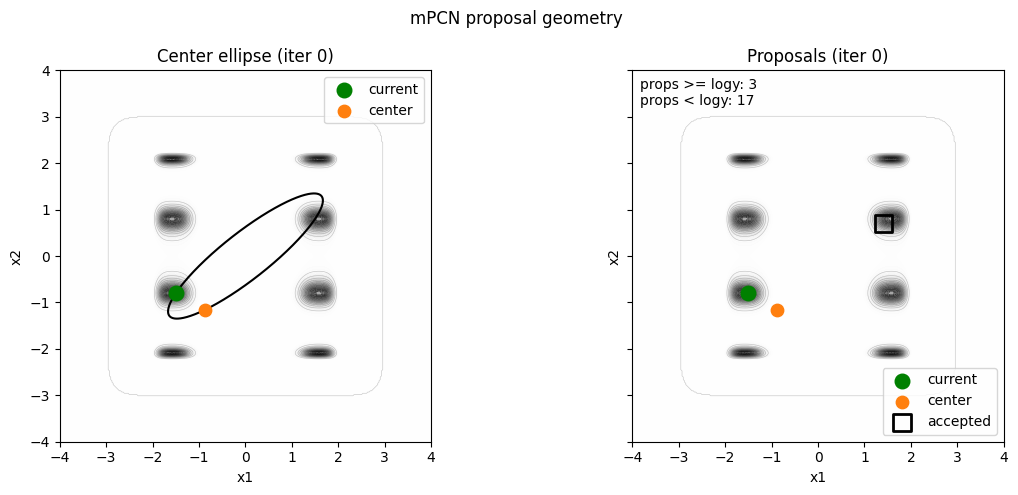

In [14]:
# Proposal illustrations for selected iterations (separate diagnostic run)
show_proposal_clouds = False  # Toggle proposal scatter clouds
plot_iters = [0] if not show_proposal_clouds else [nr for nr in np.arange(0, 10000, 1000)]
plot_iters = sorted(set(plot_iters))
n_iters_diag = max(plot_iters) + 1
seed_mpcn_diag = 202
rng_diag = np.random.default_rng(seed_mpcn_diag)
x0_diag = x0.copy()

grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

def plot_mpcn_snapshot(iter_idx, x, x_center, nu_c, props, candidates, logy, accepted_idx):
    mu = problem.prior_mean()
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax in axes:
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(False)
    axes[0].plot(ellipse[:, 0], ellipse[:, 1], color="black", linewidth=1.5, zorder=2)
    axes[0].scatter([x[0]], [x[1]], color="green", s=110, marker="o", label="current", zorder=3)
    axes[0].scatter([x_center[0]], [x_center[1]], color="tab:orange", s=80, marker="o", label="center", zorder=3)
    axes[0].set_title(f"Center ellipse (iter {iter_idx})")
    axes[0].legend(loc="upper right")

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    n_above = int(np.sum(above))
    n_below = int(props.shape[0] - n_above)
    axes[1].scatter([x[0]], [x[1]], color="green", s=110, marker="o", label="current", zorder=3)
    axes[1].scatter([x_center[0]], [x_center[1]], color="tab:orange", s=80, marker="o", label="center", zorder=3)
    if show_proposal_clouds:
        axes[1].scatter(props[~above, 0], props[~above, 1], color="teal", s=10, alpha=0.8, label="props < logy", zorder=2)
        axes[1].scatter(props[above, 0], props[above, 1], color="teal", s=10, alpha=0.8, label="props >= logy", zorder=2)
    accepted_point = candidates[accepted_idx]
    axes[1].scatter([accepted_point[0]], [accepted_point[1]], facecolors="none", edgecolors="black",
                    s=160, marker="s", linewidths=2.0, label="accepted", zorder=4)
    axes[1].text(
        0.02,
        0.98,
        f"props >= logy: {n_above}\nprops < logy: {n_below}",
        transform=axes[1].transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    axes[1].set_title(f"Proposals (iter {iter_idx})")
    axes[1].legend(loc="lower right")
    fig.suptitle("mPCN proposal geometry")
    fig.tight_layout()
    plt.show()

snapshots = {}
x = x0_diag.copy()
for t in range(n_iters_diag):
    log_l0 = problem.log_likelihood(x)
    logy = log_l0 + np.log(rng_diag.uniform())
    x_new, idx, diag = mpcn_step(
        x,
        problem,
        rng_diag,
        rho=rho,
        n_props=n_props,
        return_idx=True,
        return_diagnostics=True,
    )
    if t in plot_iters:
        snapshots[t] = (
            x.copy(),
            diag["x_center"].copy(),
            diag["nu_c"].copy(),
            diag["props"].copy(),
            diag["candidates"].copy(),
            logy,
            idx,
        )
    x = x_new

for t in plot_iters:
    x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap = snapshots[t]
    plot_mpcn_snapshot(t, x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap)

Looking for style at ../reports/figure_style.py
Saved ../reports/multiwell/likelihood_contours_multiwell_sigma1p0_prior1_grid300_seed202.png


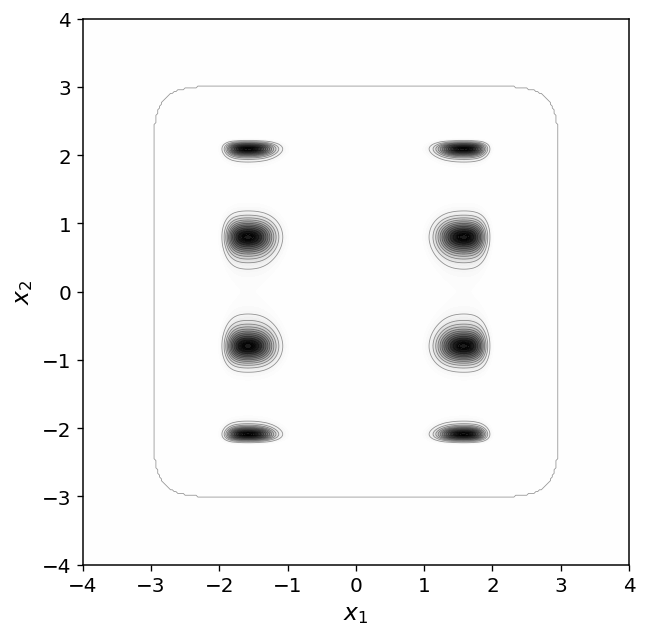

In [24]:
# Publication-quality likelihood contours (multiwell)
import sys
# from pathlib import Path

reports_root = Path("../reports")
reports_root.mkdir(parents=True, exist_ok=True)
fig_dir = reports_root / "multiwell"
fig_dir.mkdir(parents=True, exist_ok=True)

style_path = reports_root / "figure_style.py"
print(f"Looking for style at {style_path}")
if style_path.exists() and str(reports_root) not in sys.path:
    sys.path.insert(0, str(reports_root))
try:
    from figure_style import apply_pub_style
    apply_pub_style()
except Exception:
    print("Could not apply publication style (figure_style.py). Proceeding with default matplotlib style.")
    pass

grid_min = -4.0
grid_max = 4.0
grid_n = 300
grid = np.linspace(grid_min, grid_max, grid_n)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like = np.exp(log_like)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.2), constrained_layout=True)
levels_fill = 50
levels_line = 14
ax.contourf(X1, X2, like, levels=levels_fill, cmap="Grays", alpha=0.9)
ax.contour(X1, X2, like, levels=levels_line, colors="black", linewidths=0.5, alpha=0.4)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
# ax.set_title("Multiwell likelihood contours")

def _fmt(val):
    return str(val).replace(".", "p")

config_tag = f"sigma{_fmt(sigma_noise)}_prior{_fmt(prior_std)}_grid{grid_n}_seed{seed_mcmc}"
fig_path = fig_dir / f"likelihood_contours_multiwell_{config_tag}.png"
fig.savefig(fig_path, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

In [49]:
# Runtime + ESS/MSJD per minute
burn_in_metric = 500
max_lag = 1500

def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def summarize_chain_metrics(chain, runtime_sec, label):
    post = chain[burn_in_metric:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f"{label} runtime (min): {runtime_min:.2f}")
    print(f"{label} mean ESS: {ess_mean:.1f}")
    print(f"{label} mean MSJD: {msjd_mean:.4g}")
    print(f"{label} ESS per minute: {ess_per_min:.2f}")
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }

metrics_mpcn = summarize_chain_metrics(chain_mpcn, runtime_mpcn_sec, 'mPCN')
metrics_pcn = None
if run_pcn and chain_pcn is not None:
    metrics_pcn = summarize_chain_metrics(chain_pcn, runtime_pcn_sec, 'pCN (chain 0)')
else:
    print('Skipping pCN metrics (run_pcn=False).')
metrics_mess = None
if run_mess and chain_mess is not None:
    metrics_mess = summarize_chain_metrics(chain_mess, runtime_mess_sec, 'MESS (M=5)')
else:
    print('Skipping MESS metrics (run_mess=False).')

Estimating ESS for each parameter.
mPCN runtime (min): 0.07
mPCN mean ESS: 6770.4
mPCN mean MSJD: 1.666
mPCN ESS per minute: 103117.65
Estimating ESS for each parameter.
pCN (chain 0) runtime (min): 0.01
pCN (chain 0) mean ESS: 481.6
pCN (chain 0) mean MSJD: 0.1852
pCN (chain 0) ESS per minute: 73754.54
Estimating ESS for each parameter.
MESS (M=5) runtime (min): 0.02
MESS (M=5) mean ESS: 16983.4
MESS (M=5) mean MSJD: 2.814
MESS (M=5) ESS per minute: 995294.36


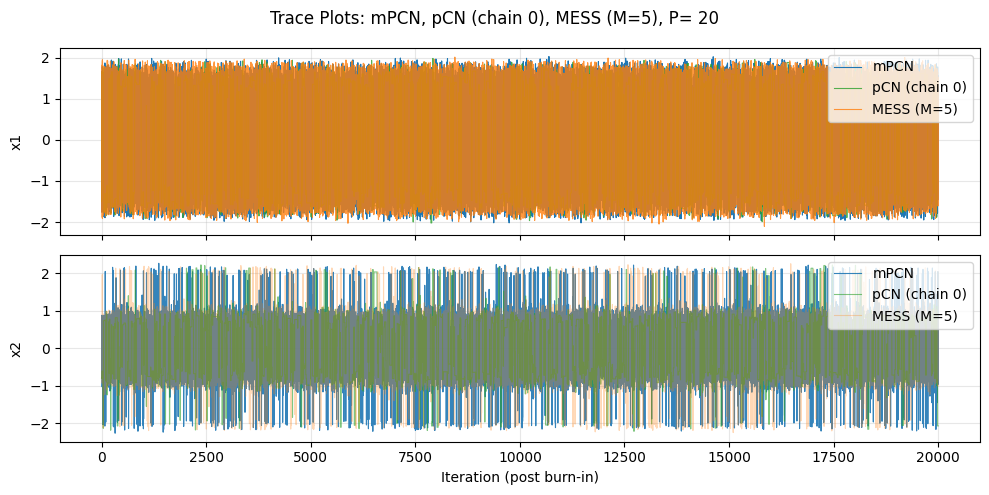

In [50]:
burn_in = 0
post_chain_mpcn = chain_mpcn[burn_in:]
post_chain_pcn = chain_pcn[burn_in:] if run_pcn and chain_pcn is not None else None
post_chain_mess = chain_mess[burn_in:] if run_mess and chain_mess is not None else None

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(post_chain_mpcn[:, 0], color='tab:blue', linewidth=0.8, label='mPCN')
if post_chain_pcn is not None:
    axes[0].plot(post_chain_pcn[:, 0], color='tab:green', linewidth=0.8, alpha=0.8, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[0].plot(post_chain_mess[:, 0], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[0].set_ylabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(post_chain_mpcn[:, 1], color='tab:blue', linewidth=0.8, alpha=0.9, label='mPCN')
if post_chain_pcn is not None:
    axes[1].plot(post_chain_pcn[:, 1], color='tab:green', linewidth=0.8, alpha=0.6, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[1].plot(post_chain_mess[:, 1], color='tab:orange', linewidth=0.8, alpha=0.3, label='MESS (M=5)')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration (post burn-in)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

title_parts = ['mPCN']
if post_chain_pcn is not None:
    title_parts.append('pCN (chain 0)')
if post_chain_mess is not None:
    title_parts.append('MESS (M=5)')
fig.suptitle(f"Trace Plots: {', '.join(title_parts)}, P= {n_props}")
fig.tight_layout()
plt.show()

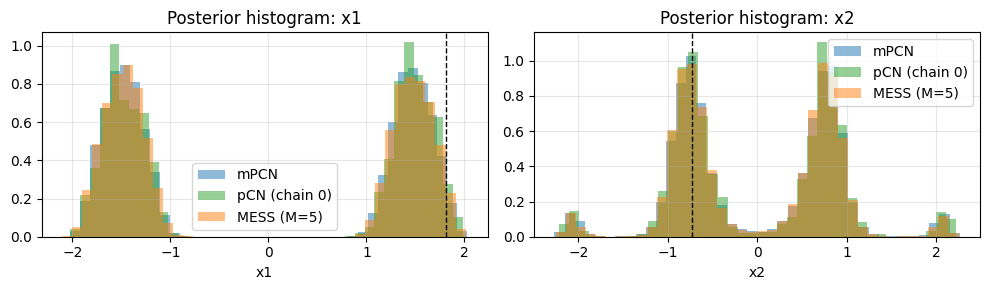

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bins = 40
axes[0].hist(post_chain_mpcn[:, 0], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_pcn is not None:
    axes[0].hist(post_chain_pcn[:, 0], bins=bins, density=True, color='tab:green', alpha=0.5, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[0].hist(post_chain_mess[:, 0], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[0].axvline(prior_sample[0], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Posterior histogram: x1')
axes[0].set_xlabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

axes[1].hist(post_chain_mpcn[:, 1], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_pcn is not None:
    axes[1].hist(post_chain_pcn[:, 1], bins=bins, density=True, color='tab:green', alpha=0.5, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[1].hist(post_chain_mess[:, 1], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[1].axvline(prior_sample[1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Posterior histogram: x2')
axes[1].set_xlabel('x2')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

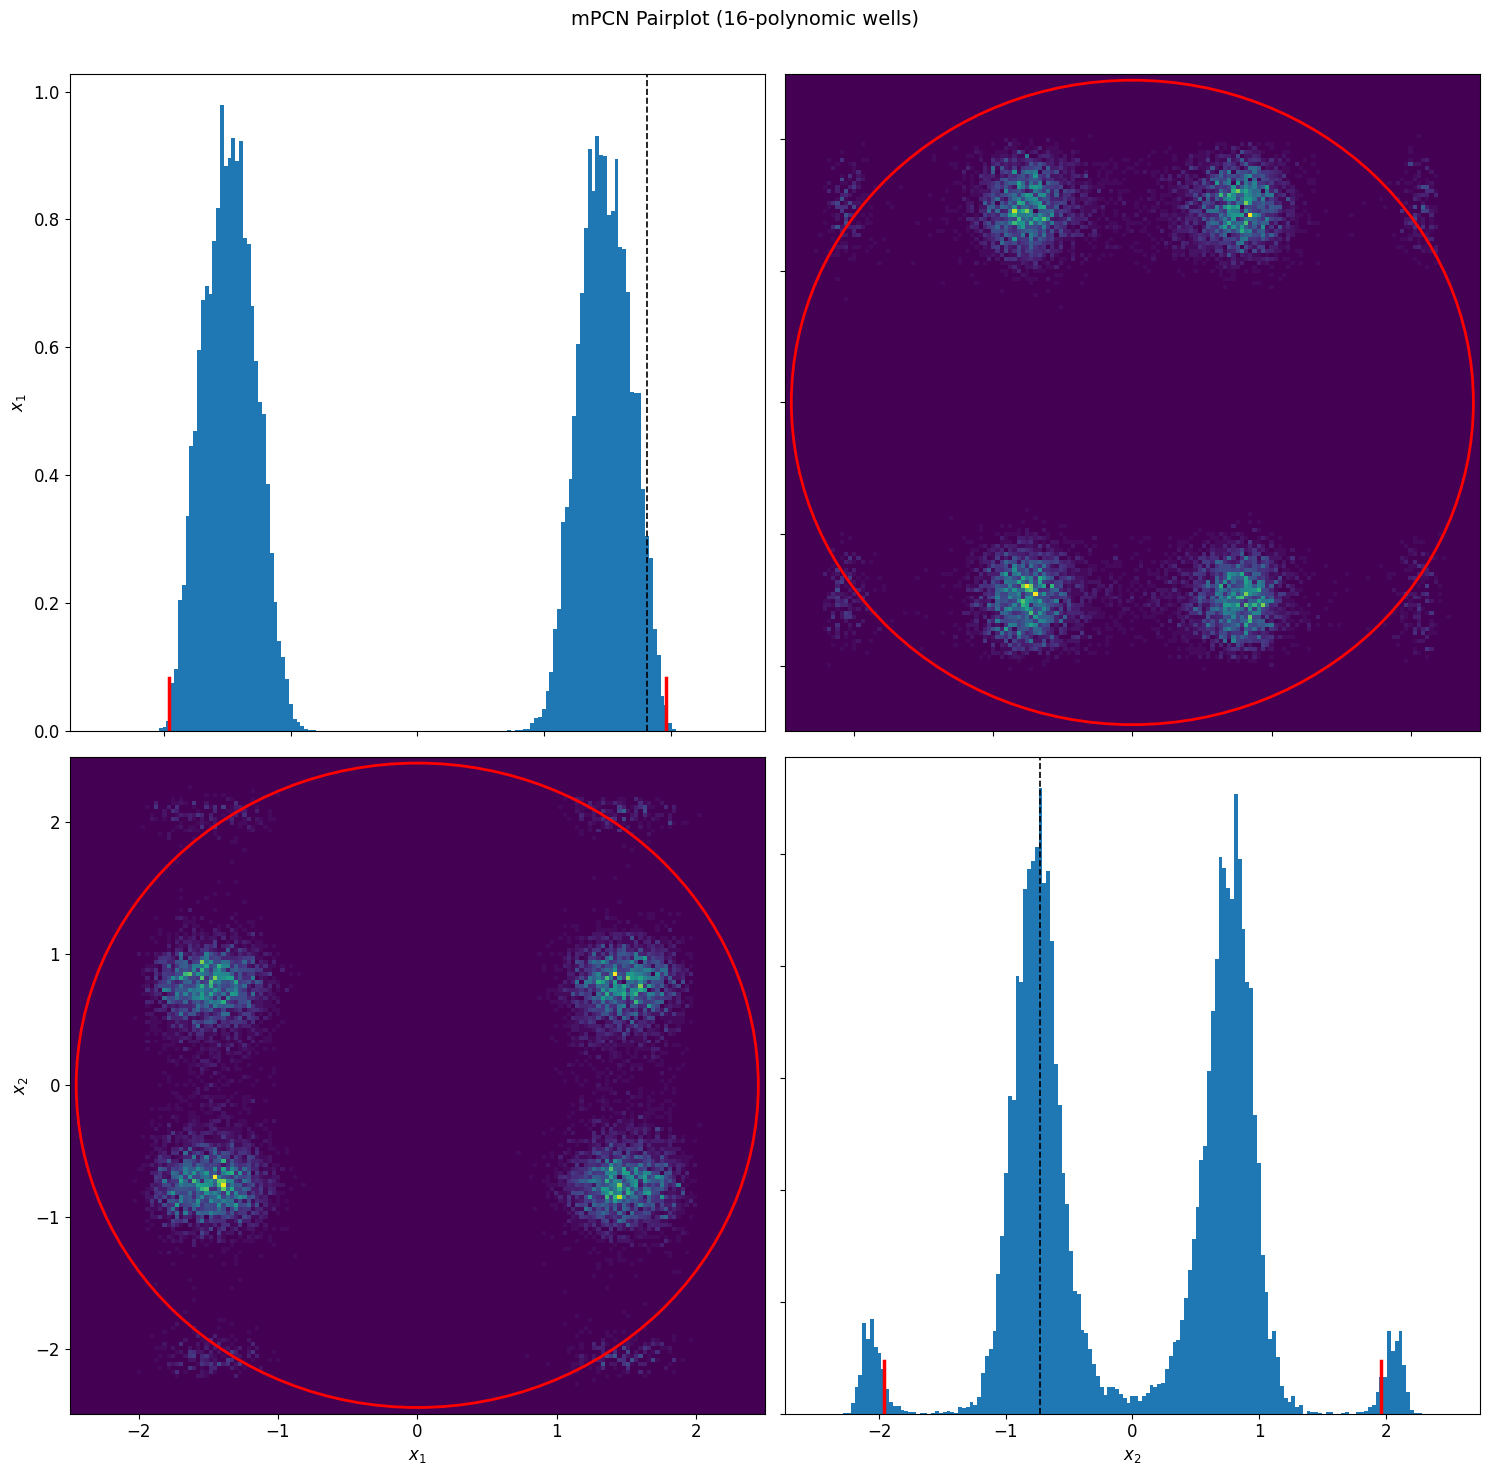

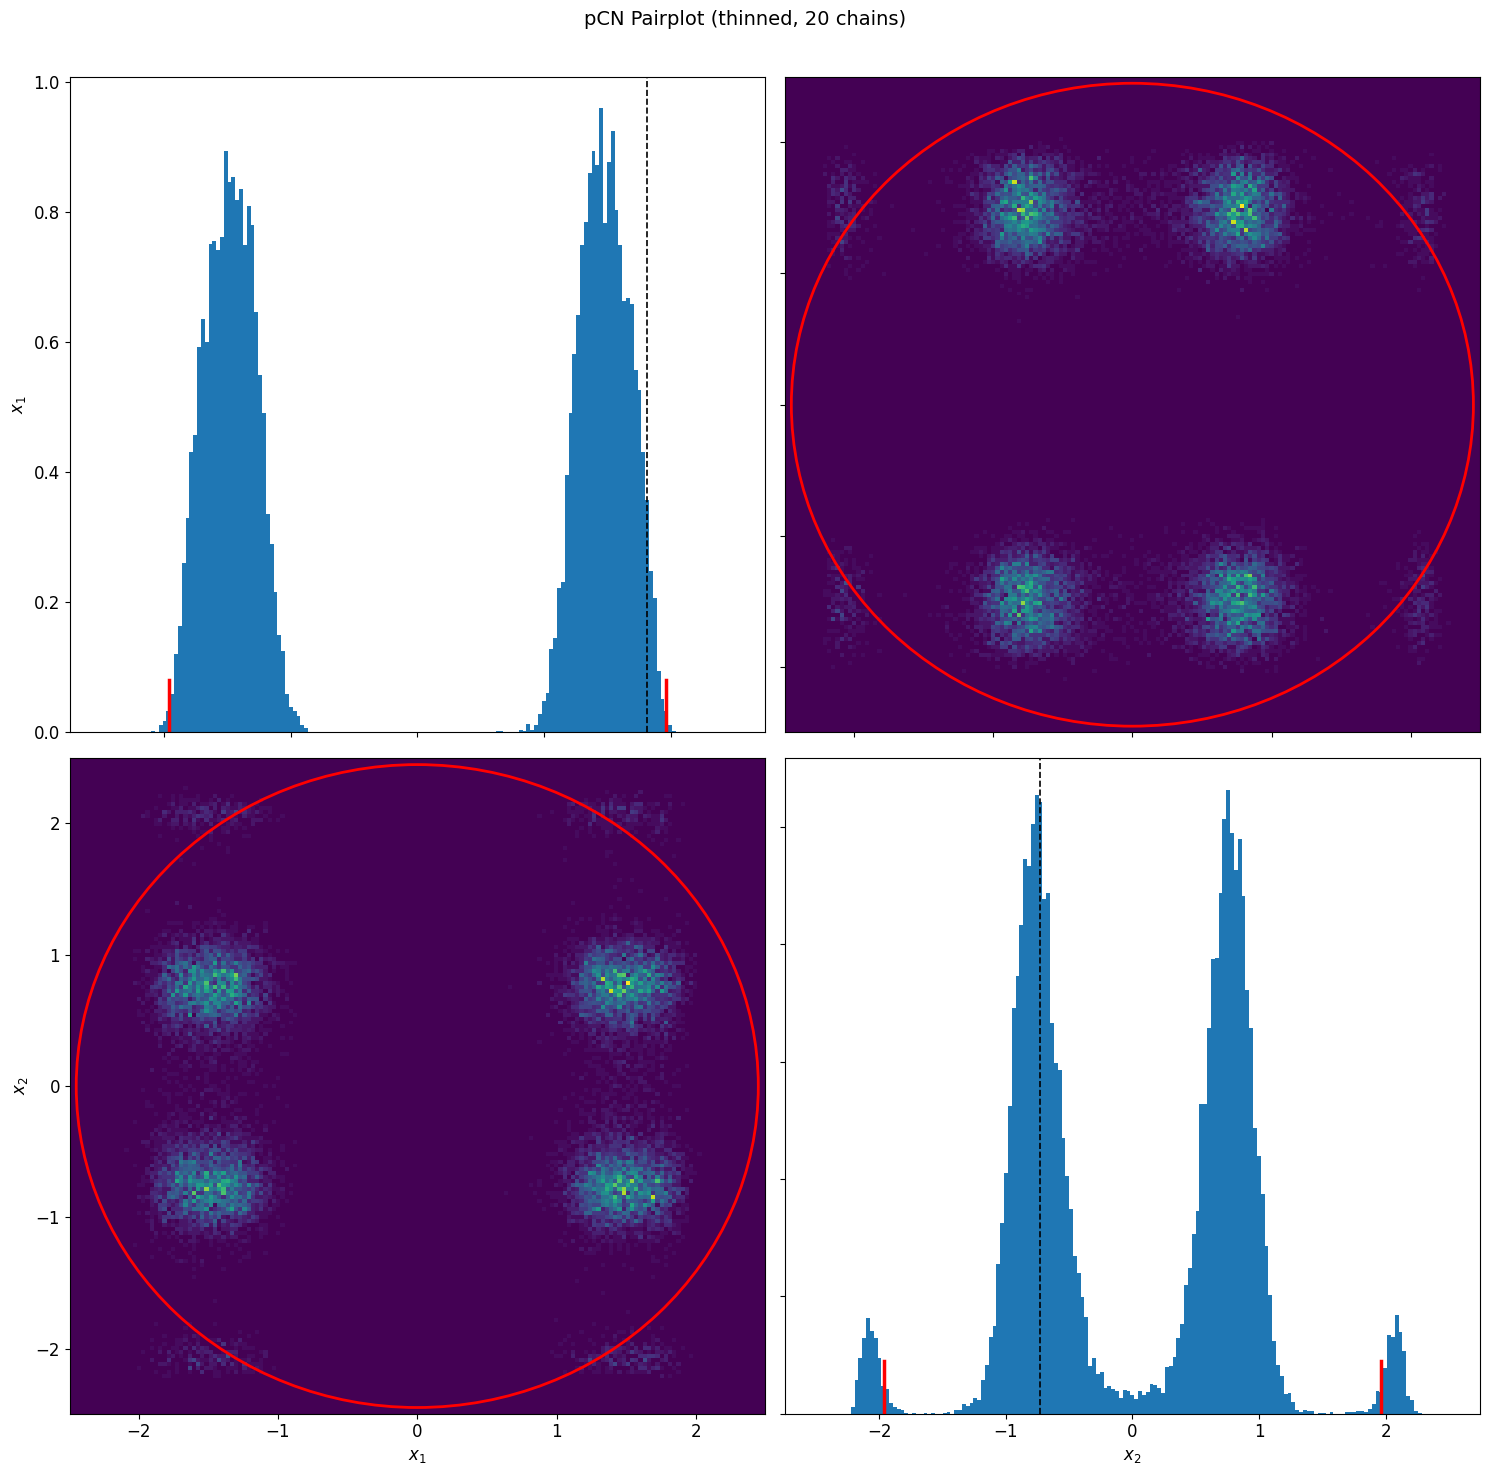

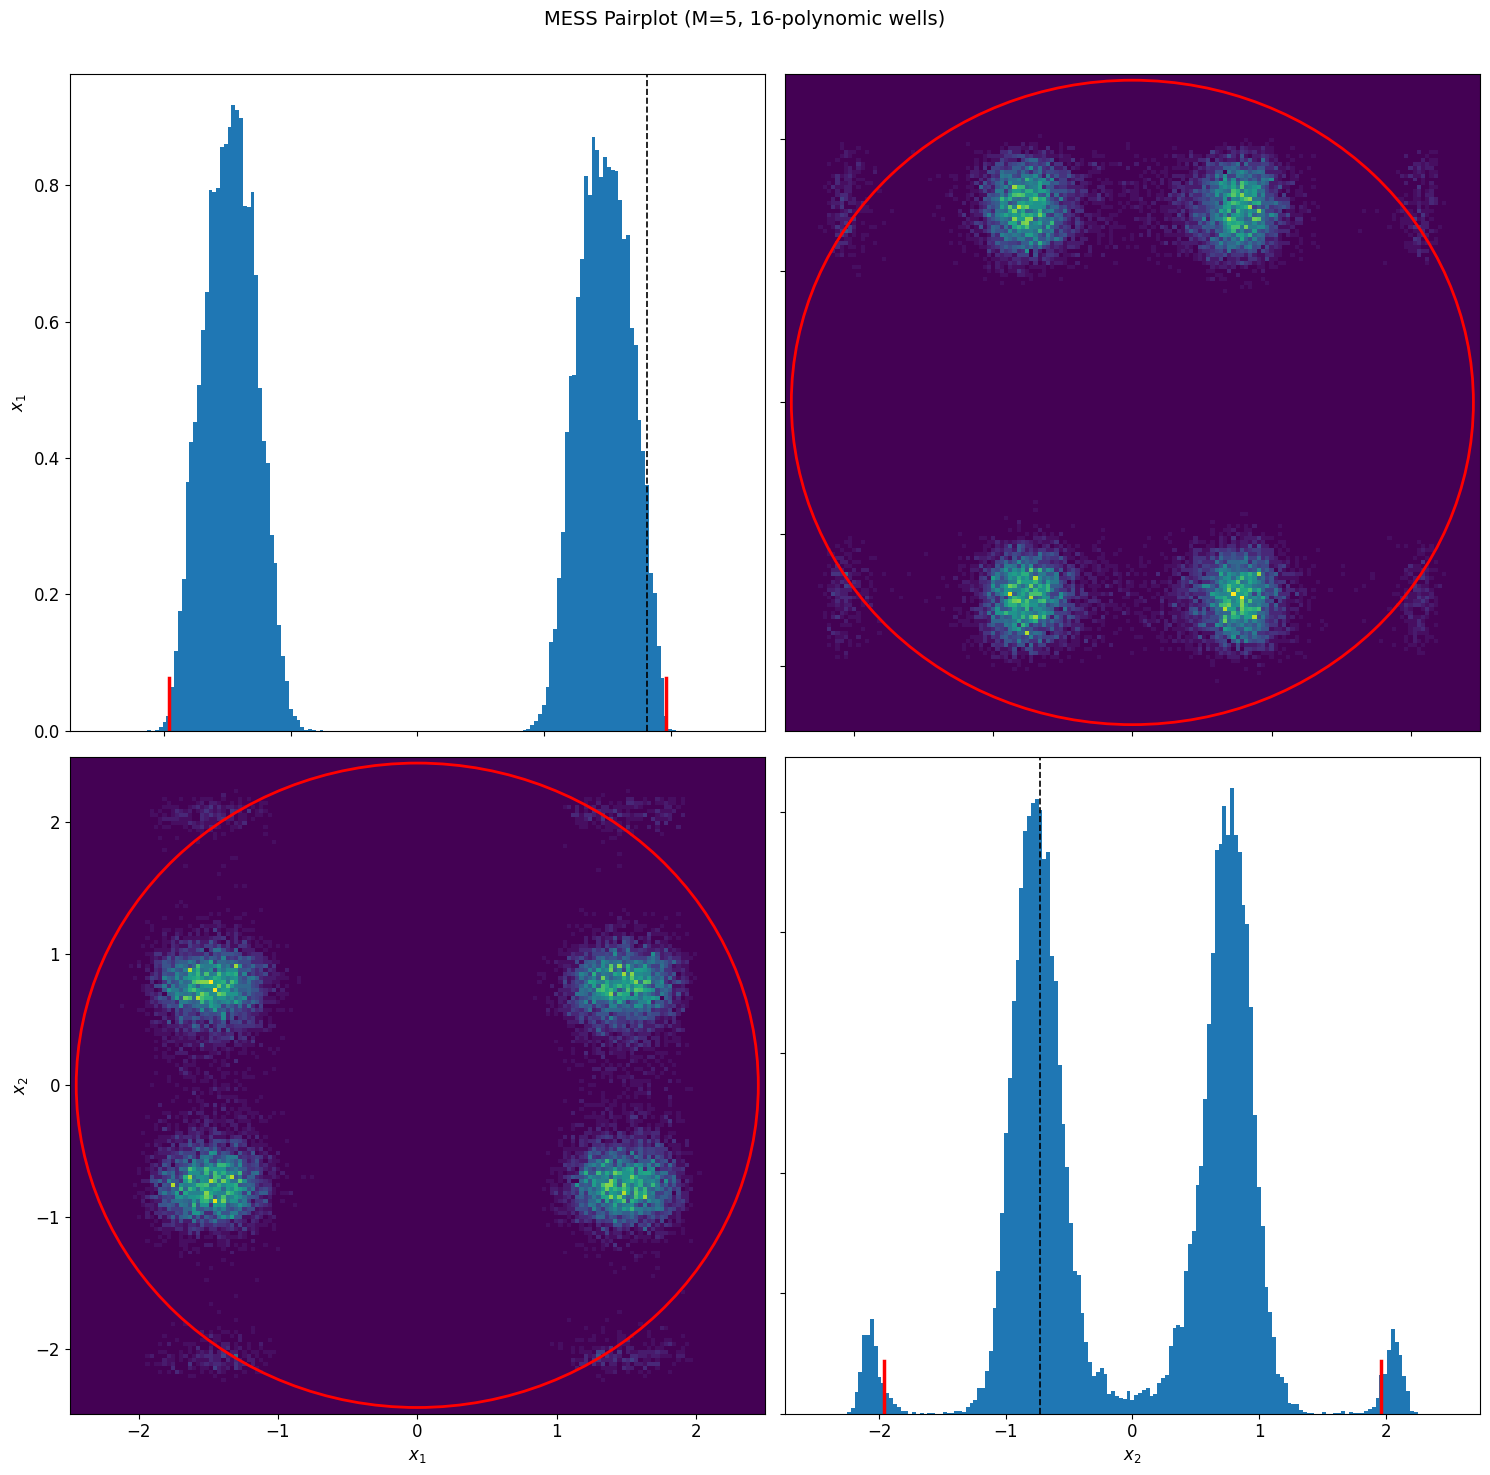

In [52]:
pcn_pair_samples = None
if run_pcn and pcn_chains is not None:
    pcn_pair_samples = np.vstack(
        [chain[burn_in::pcn_thin_step] for chain in pcn_chains]
    )

combined_list = [post_chain_mpcn]
if pcn_pair_samples is not None:
    combined_list.append(pcn_pair_samples)
if post_chain_mess is not None:
    combined_list.append(post_chain_mess)
combined = np.vstack(combined_list)
R = 1.1 * np.max(np.abs(combined))
dr = 0.03

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mPCN Pairplot (16-polynomic wells)',
    true_values=prior_sample,
 )

if pcn_pair_samples is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=pcn_pair_samples,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title=f'pCN Pairplot (thinned, {num_ind_chains} chains)',
        true_values=prior_sample,
    )

if post_chain_mess is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=post_chain_mess,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title='MESS Pairplot (M=5, 16-polynomic wells)',
        true_values=prior_sample,
    )

In [26]:
# Save results to estimations folder
estimations_root = Path('../estimations')
estimations_root.mkdir(parents=True, exist_ok=True)

config = {
    'model': 'multiwell',
    'algorithm': 'mpcn',
    'n_iters': n_iters,
    'rho': rho,
    'n_props': n_props,
    'mess_M': mess_M,
    'run_mess': run_mess,
    'run_pcn': run_pcn,
    'num_ind_chains': num_ind_chains,
    'pcn_max_workers': pcn_max_workers,
    'pcn_thin_step': pcn_thin_step,
    'pcn_start_points': [pt.tolist() for pt in pcn_start_points],
    'pcn_start_points_full': [pt.tolist() for pt in pcn_start_points_full],
    'pcn_seeds': pcn_seeds,
    'seed_mcmc': seed_mcmc,
    'sigma_noise': sigma_noise,
    'prior_std': prior_std,
    'prior_cov': prior_cov.tolist(),
    'burn_in_metric': burn_in_metric,
    'n_jobs': n_jobs,
    'core_frac': core_frac,
    'parallel_backend': parallel_backend,
    'accept_rate_pcn': accept_rate_pcn,
    'accept_rate_pcn_all': accept_rate_pcn_all,
}

config_json = json.dumps(config, sort_keys=True)
config_hash = hashlib.sha256(config_json.encode('utf-8')).hexdigest()[:12]
run_name = (
    f'multiwell_mpcn_P{n_props}_rho{rho}_iters{n_iters}_seed{seed_mcmc}_'
    f'pcnC{num_ind_chains}_h{config_hash}'
 )
run_dir = estimations_root / 'multiwell' / 'mpcn' / run_name
run_dir.mkdir(parents=True, exist_ok=True)

with open(run_dir / 'config.json', 'w', encoding='utf-8') as f:
    f.write(config_json)

np.savez_compressed(
    run_dir / 'samples.npz',
    chain_mpcn=chain_mpcn,
    accepted_index=accepted_index,
    chain_pcn=chain_pcn,
    pcn_chains=pcn_chains,
    pcn_start_points_full=np.array(pcn_start_points_full),
    pcn_seeds=np.array(pcn_seeds),
    accept_rate_pcn=accept_rate_pcn,
    accept_rate_pcn_all=accept_rate_pcn_all,
    chain_mess=chain_mess,
    prior_sample=prior_sample,
    y_obs=y_obs,
    runtime_mpcn_sec=runtime_mpcn_sec,
    runtime_pcn_sec=runtime_pcn_sec,
    runtime_mess_sec=runtime_mess_sec,
    metrics_mpcn=metrics_mpcn,
    metrics_pcn=metrics_pcn,
    metrics_mess=metrics_mess,
 )

with open(run_dir / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'mpcn': metrics_mpcn,
        'pcn': metrics_pcn,
        'mess': metrics_mess,
        'runtime_mpcn_sec': runtime_mpcn_sec,
        'runtime_pcn_sec': runtime_pcn_sec,
        'runtime_mess_sec': runtime_mess_sec,
        'accept_rate_pcn': accept_rate_pcn,
        'accept_rate_pcn_all': accept_rate_pcn_all,
        'num_ind_chains': num_ind_chains,
    }, f, indent=2)

print('Saved run to:', run_dir)

Saved run to: ../estimations/multiwell/mpcn/multiwell_mpcn_P20_rho0.1_iters50000_seed202_pcnC4_h22f071bf7aa8


## Random-start convergence study

Replicate the mPCN, pCN, and MESS runs using random initial points to study convergence behavior. The first pCN chain, mPCN, and MESS start from the same random point. Remaining pCN chains start from additional random points (same seed, different draws).

In [71]:
# Random-start configuration
if num_ind_chains < 1:
    raise ValueError('num_ind_chains must be >= 1')
rng_rand = np.random.default_rng(seed_mcmc)

# Random starts from the (x1, x2) support; adjust bounds as needed
support_min = np.array([-4.0, -4.0], dtype=float)
support_max = np.array([4.0, 4.0], dtype=float)
x0_rand = rng_rand.uniform(low=support_min, high=support_max)

pcn_start_points_rand = [x0_rand.copy()]
for _ in range(num_ind_chains - 1):
    pcn_start_points_rand.append(rng_rand.uniform(low=support_min, high=support_max))
pcn_start_points_rand = [pt.copy() for pt in pcn_start_points_rand]
pcn_seeds_rand = [seed_mcmc for _ in range(num_ind_chains)]
pcn_max_workers_rand = min(num_ind_chains, os.cpu_count() or 1)
pcn_thin_step_rand = max(1, num_ind_chains)
print('Random start (x0_rand):', x0_rand)

Random start (x0_rand): [-1.2297     -0.45075274]


In [72]:
# mPCN chain (random start)
t0 = time.perf_counter()
chain_mpcn_rand, accepted_index_rand = mpcn_chain(
    x0_rand,
    problem,
    np.random.default_rng(seed_mcmc),
    n_iters,
    rho=rho,
    n_props=n_props,
    n_jobs=n_jobs,
    core_frac=core_frac,
    parallel_backend=parallel_backend,
    return_indices=True,
 )
runtime_mpcn_rand_sec = time.perf_counter() - t0

accept_rate_rand = np.mean(accepted_index_rand != 0)
accepted_idx_rand = accepted_index_rand.astype(int)
print(f'mPCN (random start) acceptance rate (state changed): {accept_rate_rand:.3f}')
print('mPCN (random start) accepted indices (first 20):', accepted_idx_rand[:20])
print(f'mPCN (random start) runtime (sec): {runtime_mpcn_rand_sec:.2f}')

mPCN (random start) acceptance rate (state changed): 0.565
mPCN (random start) accepted indices (first 20): [ 0 13  7 11 15  6  0  5 18 16 16  0  4  0  0  3  0  0  0  0]
mPCN (random start) runtime (sec): 4.06


In [73]:
# pCN chains (random start, multiprocessing)
if run_pcn:
    worker_args_rand = [
        (i, pcn_seeds_rand[i], pcn_start_points_rand[i].copy())
        for i in range(num_ind_chains)
    ]
    t0 = time.perf_counter()
    if num_ind_chains == 1:
        results_rand = [_run_pcn_chain_worker(worker_args_rand[0])]
    else:
        with ProcessPoolExecutor(
            max_workers=pcn_max_workers_rand,
            mp_context=get_context("fork"),
        ) as executor:
            results_rand = list(executor.map(_run_pcn_chain_worker, worker_args_rand))
    runtime_pcn_rand_sec = time.perf_counter() - t0

    results_rand.sort(key=lambda item: item[0])
    pcn_chains_rand = np.stack([item[1] for item in results_rand], axis=0)
    accept_rate_pcn_all_rand = [float(item[2]) for item in results_rand]
    chain_pcn_rand = pcn_chains_rand[0]
    accept_rate_pcn_rand = accept_rate_pcn_all_rand[0]
    print(f'pCN (random start) acceptance rate (chain 0): {accept_rate_pcn_rand:.3f}')
    print('pCN (random start) accept rates (all chains):', np.round(accept_rate_pcn_all_rand, 3))
    print(f'pCN (random start) runtime (sec): {runtime_pcn_rand_sec:.2f}')
else:
    chain_pcn_rand = None
    pcn_chains_rand = None
    accept_rate_pcn_rand = None
    accept_rate_pcn_all_rand = None
    runtime_pcn_rand_sec = 0.0
    print('pCN disabled (run_pcn=False).')

pCN (random start) acceptance rate (chain 0): 0.079
pCN (random start) accept rates (all chains): [0.079 0.079 0.079 0.079 0.079 0.079 0.079 0.079 0.079 0.079 0.079 0.079
 0.079 0.079 0.079 0.079 0.079 0.079 0.079 0.079]
pCN (random start) runtime (sec): 0.47


In [74]:
# MESS chain (random start, no LP)
if run_mess:
    chain_mess_rand = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain_mess_rand[0] = x0_rand
    x = x0_rand.copy()
    rng_mess_rand = np.random.default_rng(seed_mcmc)
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess_rand,
            M=mess_M,
            use_lp=False,
            distance_metric='angular',
            lam=0.0,
        )
        chain_mess_rand[t + 1] = x
    runtime_mess_rand_sec = time.perf_counter() - t0
    print('MESS (random start) run completed.')
    print(f'MESS (random start) runtime (sec): {runtime_mess_rand_sec:.2f}')
else:
    chain_mess_rand = None
    runtime_mess_rand_sec = 0.0
    print('MESS disabled (run_mess=False).')

MESS (random start) run completed.
MESS (random start) runtime (sec): 0.98


In [75]:
# Random-start metrics
metrics_mpcn_rand = summarize_chain_metrics(chain_mpcn_rand, runtime_mpcn_rand_sec, 'mPCN (random start)')
metrics_pcn_rand = None
if run_pcn and chain_pcn_rand is not None:
    metrics_pcn_rand = summarize_chain_metrics(chain_pcn_rand, runtime_pcn_rand_sec, 'pCN (random start, chain 0)')
else:
    print('Skipping pCN random-start metrics (run_pcn=False).')
metrics_mess_rand = None
if run_mess and chain_mess_rand is not None:
    metrics_mess_rand = summarize_chain_metrics(chain_mess_rand, runtime_mess_rand_sec, 'MESS (random start)')
else:
    print('Skipping MESS random-start metrics (run_mess=False).')

Estimating ESS for each parameter.
mPCN (random start) runtime (min): 0.07
mPCN (random start) mean ESS: 6770.4
mPCN (random start) mean MSJD: 1.666
mPCN (random start) ESS per minute: 99999.53
Estimating ESS for each parameter.
pCN (random start, chain 0) runtime (min): 0.01
pCN (random start, chain 0) mean ESS: 481.6
pCN (random start, chain 0) mean MSJD: 0.1852
pCN (random start, chain 0) ESS per minute: 61003.31
Estimating ESS for each parameter.
MESS (random start) runtime (min): 0.02
MESS (random start) mean ESS: 17153.6
MESS (random start) mean MSJD: 2.82
MESS (random start) ESS per minute: 1046159.37


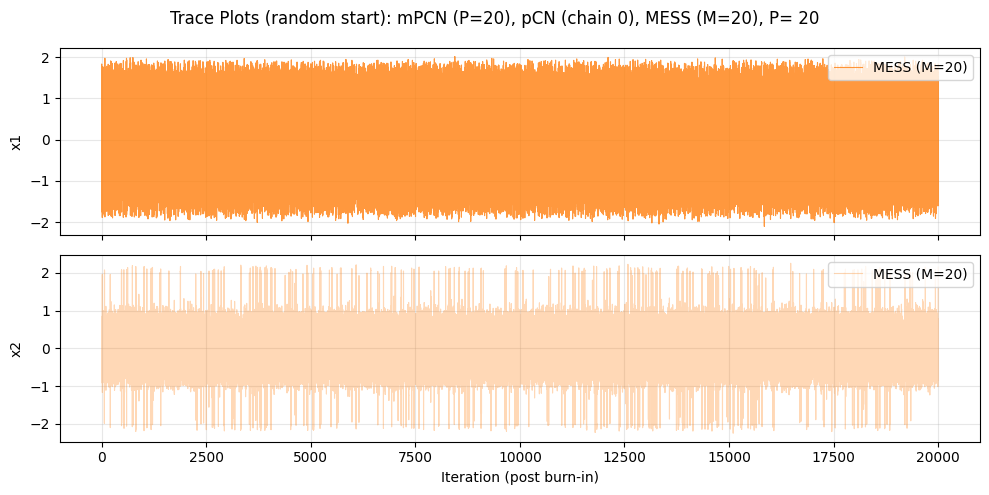

In [76]:
# Random-start trace plots
burn_in_rand = 0
post_chain_mpcn_rand = chain_mpcn_rand[burn_in_rand:]
post_chain_pcn_rand = chain_pcn_rand[burn_in_rand:] if run_pcn and chain_pcn_rand is not None else None
post_chain_mess_rand = chain_mess_rand[burn_in_rand:] if run_mess and chain_mess_rand is not None else None

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
# axes[0].plot(post_chain_mpcn_rand[:, 0], color='tab:blue', linewidth=0.8, label='mPCN')
# if post_chain_pcn_rand is not None:
#     axes[0].plot(post_chain_pcn_rand[:, 0], color='tab:green', linewidth=0.8, alpha=0.8, label='pCN (chain 0)')
if post_chain_mess_rand is not None:
    axes[0].plot(post_chain_mess_rand[:, 0], color='tab:orange', linewidth=0.8, alpha=0.8, label=f'MESS (M={mess_M})')
axes[0].set_ylabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

# axes[1].plot(post_chain_mpcn_rand[:, 1], color='tab:blue', linewidth=0.8, alpha=0.9, label='mPCN')
# if post_chain_pcn_rand is not None:
#     axes[1].plot(post_chain_pcn_rand[:, 1], color='tab:green', linewidth=0.8, alpha=0.6, label='pCN (chain 0)')
if post_chain_mess_rand is not None:
    axes[1].plot(post_chain_mess_rand[:, 1], color='tab:orange', linewidth=0.8, alpha=0.3, label=f'MESS (M={mess_M})')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration (post burn-in)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

title_parts_rand = [f'mPCN (P={n_props})']
if post_chain_pcn_rand is not None:
    title_parts_rand.append('pCN (chain 0)')
if post_chain_mess_rand is not None:
    title_parts_rand.append(f'MESS (M={mess_M})')
fig.suptitle(f"Trace Plots (random start): {', '.join(title_parts_rand)}, P= {n_props}")
fig.tight_layout()
plt.show()

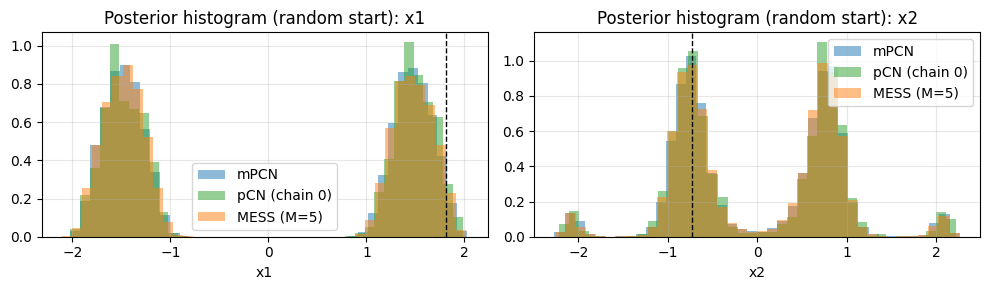

In [77]:
# Random-start histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bins = 40
axes[0].hist(post_chain_mpcn_rand[:, 0], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_pcn_rand is not None:
    axes[0].hist(post_chain_pcn_rand[:, 0], bins=bins, density=True, color='tab:green', alpha=0.5, label='pCN (chain 0)')
if post_chain_mess_rand is not None:
    axes[0].hist(post_chain_mess_rand[:, 0], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[0].axvline(prior_sample[0], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Posterior histogram (random start): x1')
axes[0].set_xlabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

axes[1].hist(post_chain_mpcn_rand[:, 1], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_pcn_rand is not None:
    axes[1].hist(post_chain_pcn_rand[:, 1], bins=bins, density=True, color='tab:green', alpha=0.5, label='pCN (chain 0)')
if post_chain_mess_rand is not None:
    axes[1].hist(post_chain_mess_rand[:, 1], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[1].axvline(prior_sample[1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Posterior histogram (random start): x2')
axes[1].set_xlabel('x2')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

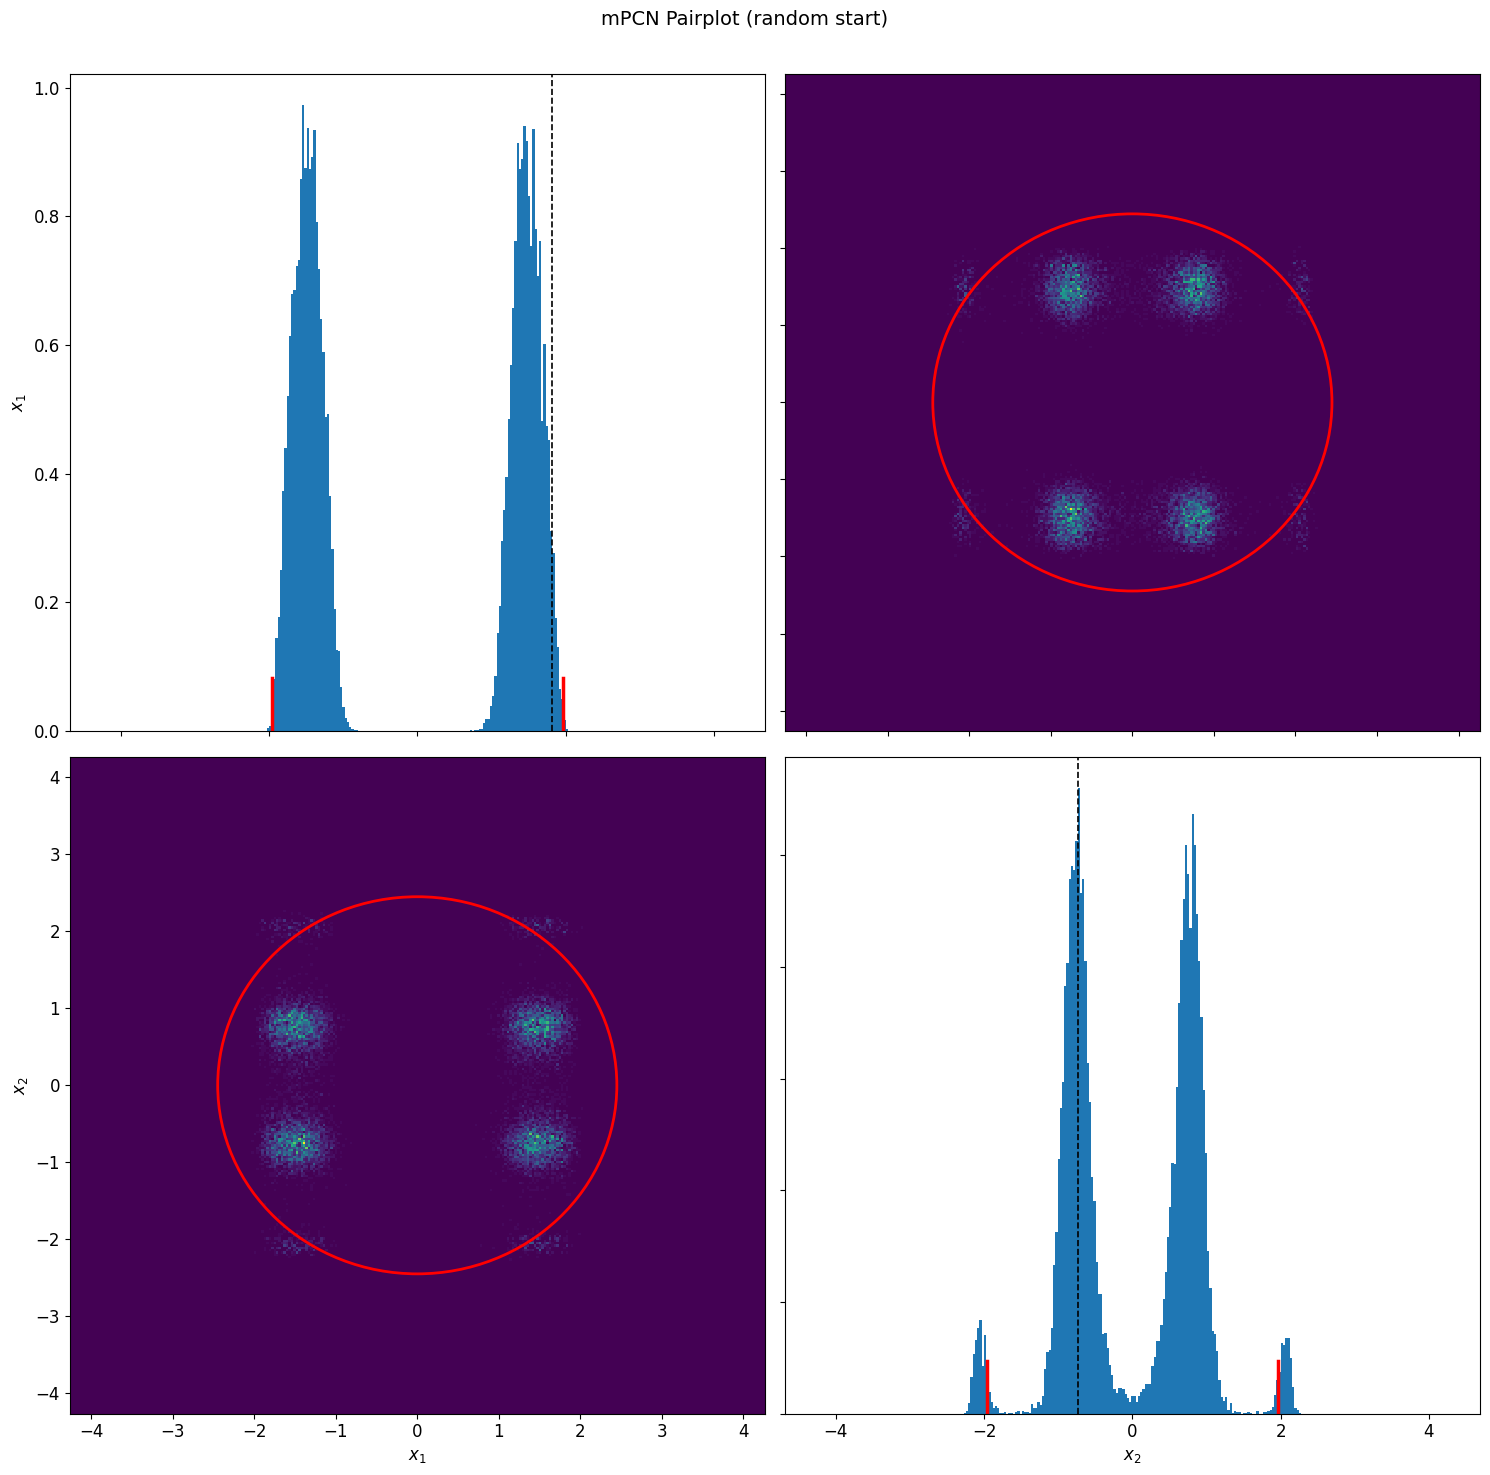

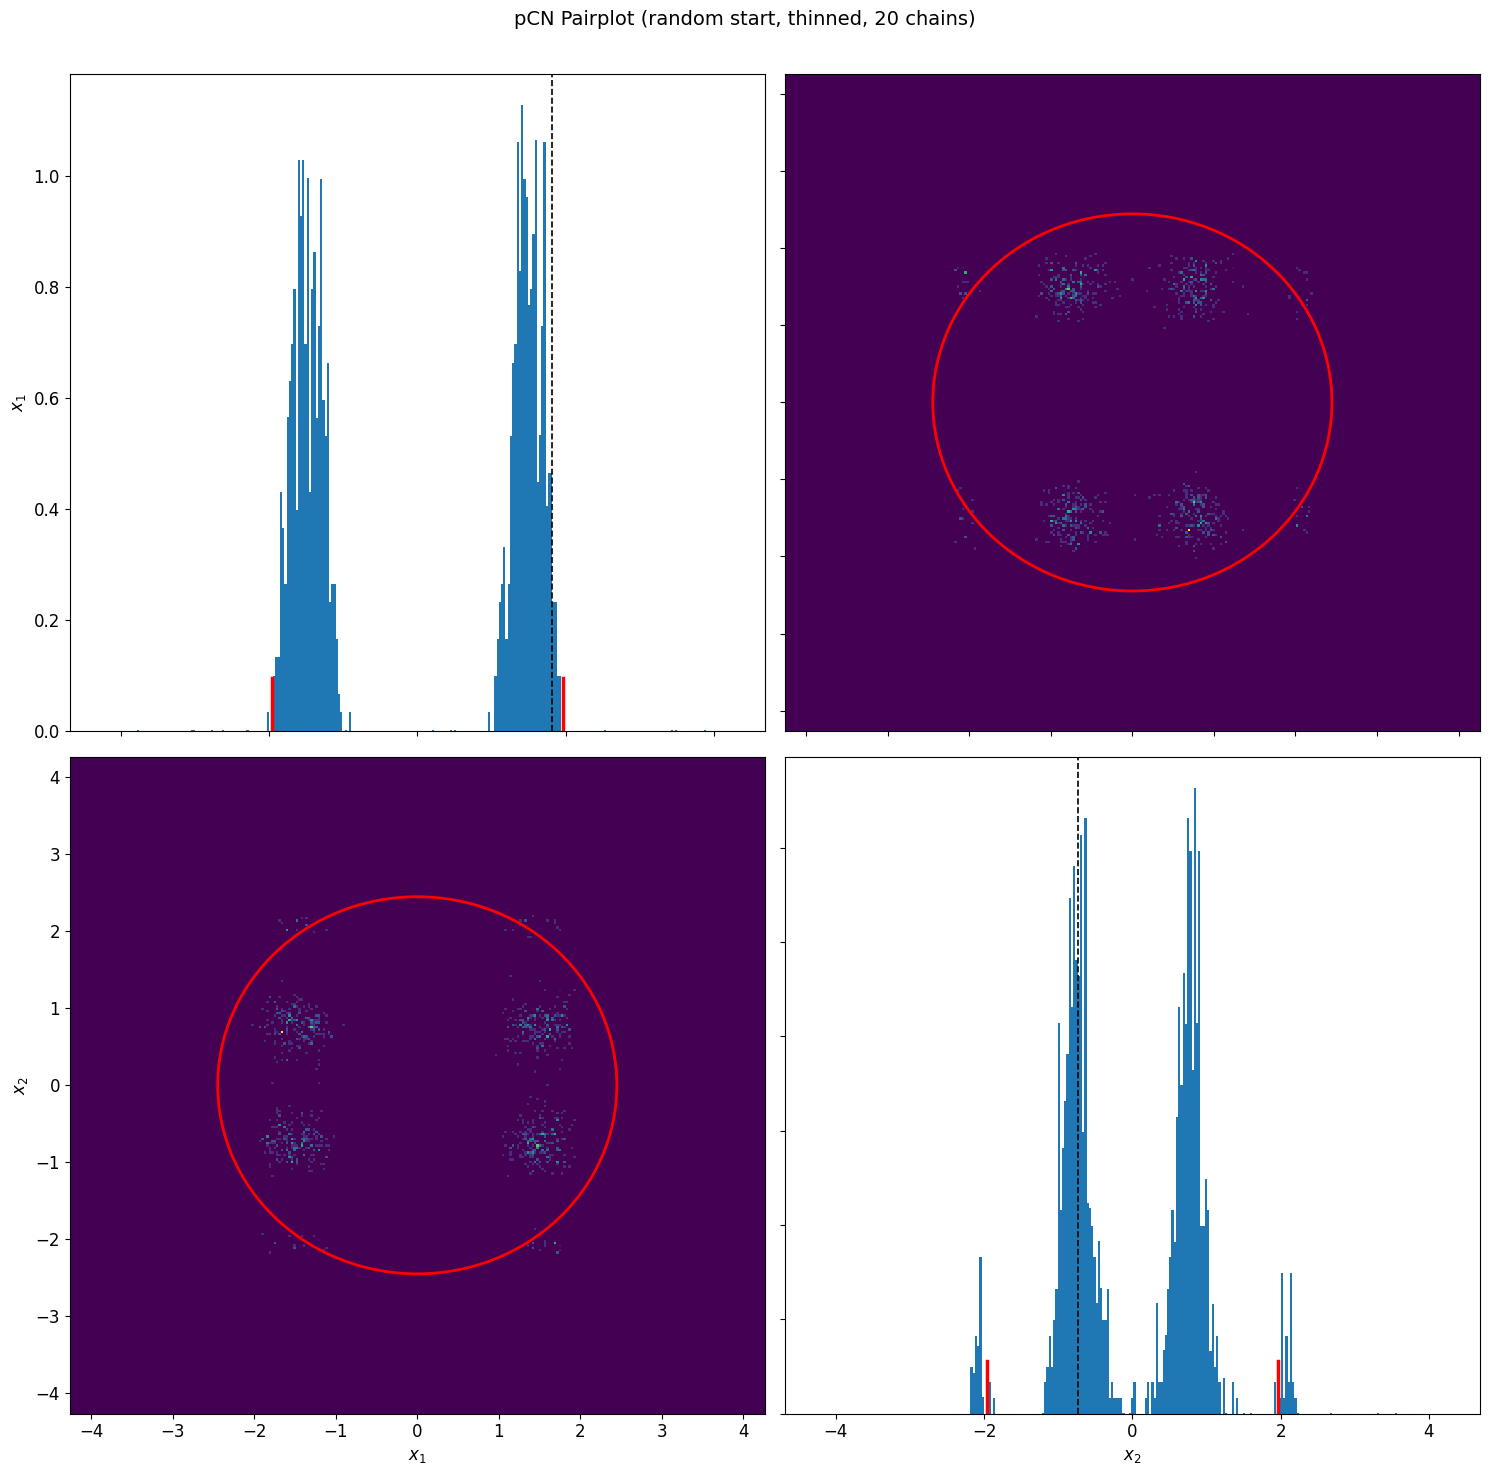

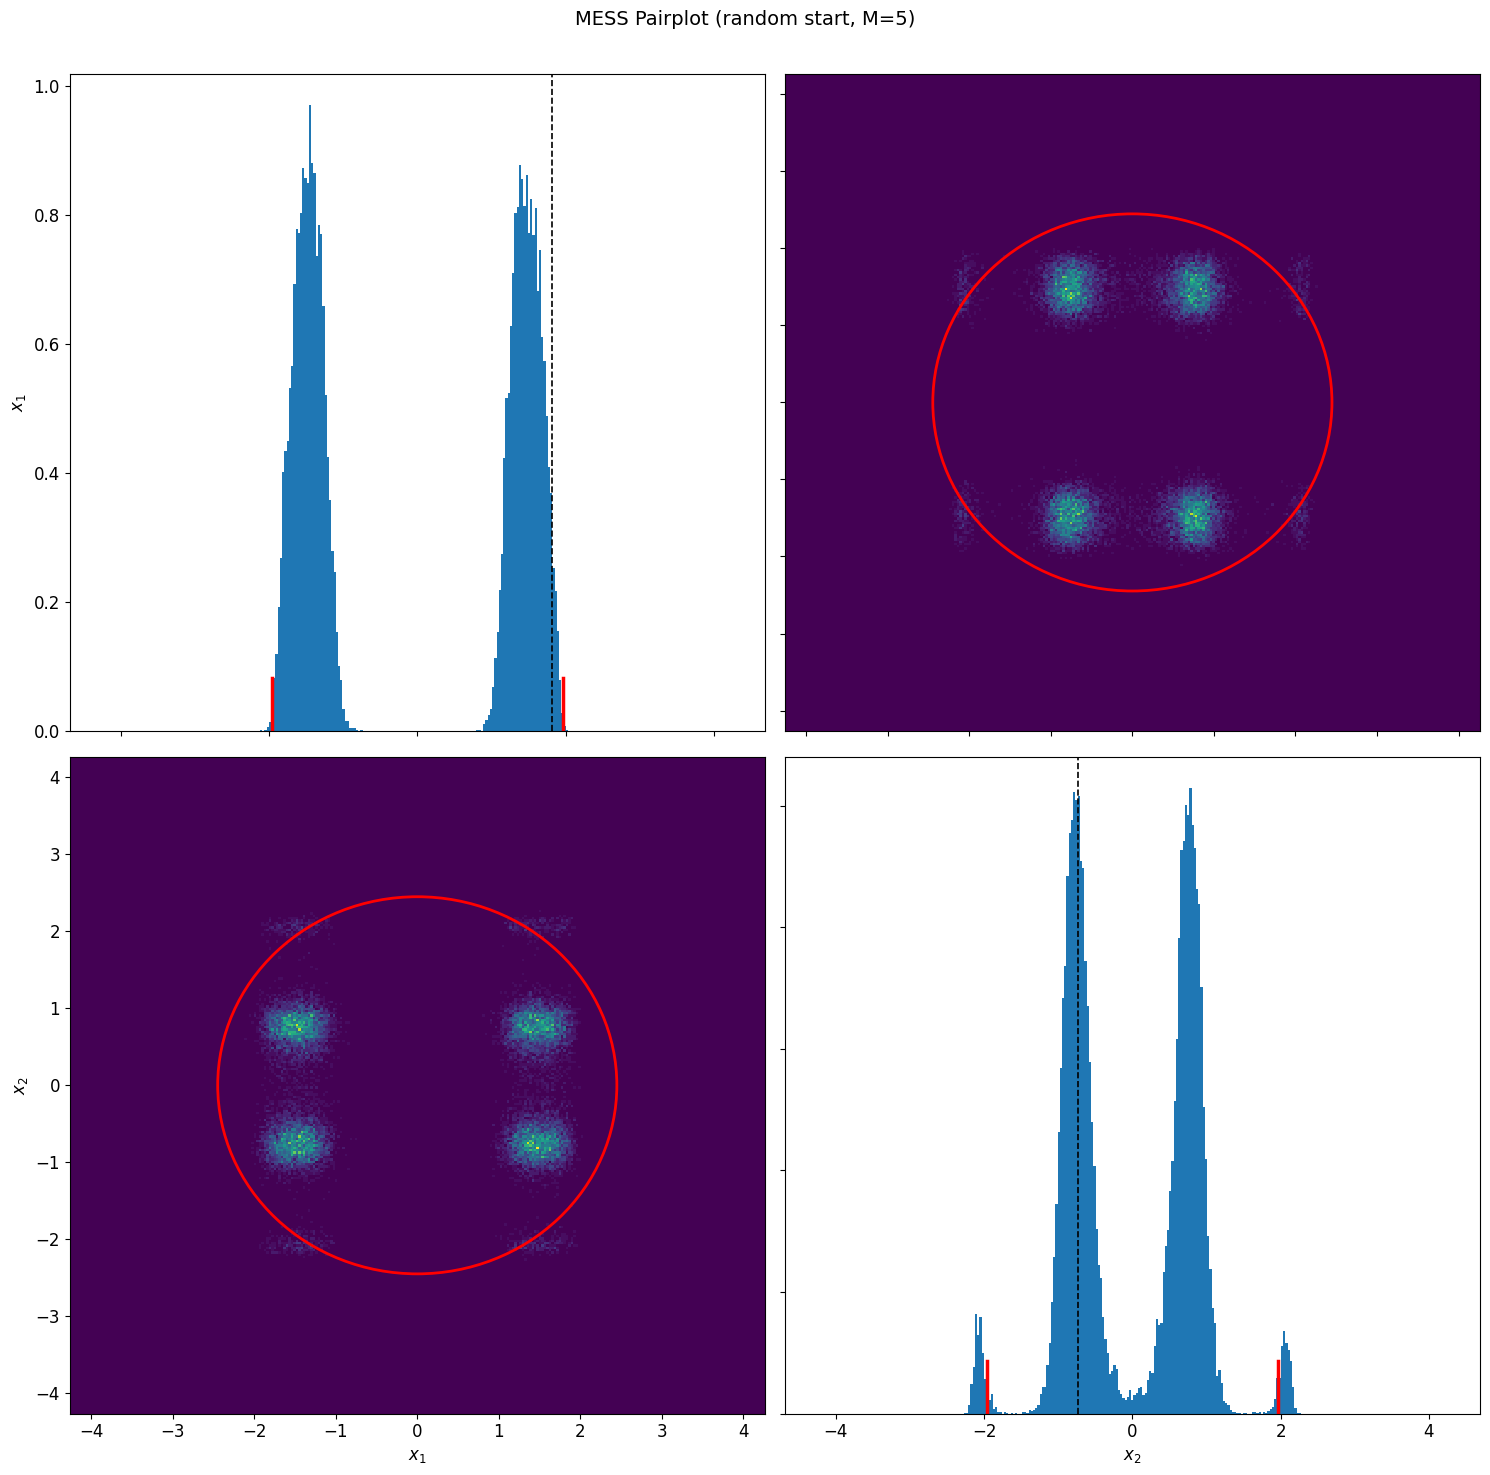

In [78]:
# Random-start pairplots
pcn_pair_samples_rand = None
if run_pcn and pcn_chains_rand is not None:
    pcn_pair_samples_rand = np.vstack(
        [chain[burn_in_rand::pcn_thin_step_rand] for chain in pcn_chains_rand]
    )

combined_list_rand = [post_chain_mpcn_rand]
if pcn_pair_samples_rand is not None:
    combined_list_rand.append(pcn_pair_samples_rand)
if post_chain_mess_rand is not None:
    combined_list_rand.append(post_chain_mess_rand)
combined_rand = np.vstack(combined_list_rand)
R_rand = 1.1 * np.max(np.abs(combined_rand))
dr_rand = dr

_ = make_hist_grid_comps(
    R=R_rand,
    dr=dr_rand,
    samples=post_chain_mpcn_rand,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mPCN Pairplot (random start)',
    true_values=prior_sample,
 )

if pcn_pair_samples_rand is not None:
    _ = make_hist_grid_comps(
        R=R_rand,
        dr=dr_rand,
        samples=pcn_pair_samples_rand,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title=f'pCN Pairplot (random start, thinned, {num_ind_chains} chains)',
        true_values=prior_sample,
    )

if post_chain_mess_rand is not None:
    _ = make_hist_grid_comps(
        R=R_rand,
        dr=dr_rand,
        samples=post_chain_mess_rand,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title='MESS Pairplot (random start, M=5)',
        true_values=prior_sample,
    )

In [ ]:
# Save random-start results
estimations_root_rand = Path('../estimations')
estimations_root_rand.mkdir(parents=True, exist_ok=True)

config_rand = {
    'model': 'multiwell',
    'algorithm': 'mpcn',
    'n_iters': n_iters,
    'rho': rho,
    'n_props': n_props,
    'mess_M': mess_M,
    'run_mess': run_mess,
    'run_pcn': run_pcn,
    'num_ind_chains': num_ind_chains,
    'pcn_max_workers': pcn_max_workers_rand,
    'pcn_thin_step': pcn_thin_step_rand,
    'pcn_start_points_rand': [pt.tolist() for pt in pcn_start_points_rand],
    'pcn_seeds_rand': pcn_seeds_rand,
    'seed_mcmc': seed_mcmc,
    'sigma_noise': sigma_noise,
    'prior_std': prior_std,
    'prior_cov': prior_cov.tolist(),
    'burn_in_metric': burn_in_metric,
    'n_jobs': n_jobs,
    'core_frac': core_frac,
    'parallel_backend': parallel_backend,
    'accept_rate_pcn_rand': accept_rate_pcn_rand,
    'accept_rate_pcn_all_rand': accept_rate_pcn_all_rand,
}

config_json_rand = json.dumps(config_rand, sort_keys=True)
config_hash_rand = hashlib.sha256(config_json_rand.encode('utf-8')).hexdigest()[:12]
run_name_rand = (
    f'multiwell_mpcn_random_start_P{n_props}_rho{rho}_iters{n_iters}_seed{seed_mcmc}_'
    f'pcnC{num_ind_chains}_h{config_hash_rand}'
 )
run_dir_rand = estimations_root_rand / 'multiwell' / 'mpcn' / run_name_rand
run_dir_rand.mkdir(parents=True, exist_ok=True)

with open(run_dir_rand / 'config.json', 'w', encoding='utf-8') as f:
    f.write(config_json_rand)

np.savez_compressed(
    run_dir_rand / 'samples.npz',
    chain_mpcn=chain_mpcn_rand,
    accepted_index=accepted_index_rand,
    chain_pcn=chain_pcn_rand,
    pcn_chains=pcn_chains_rand,
    pcn_start_points_rand=np.array(pcn_start_points_rand),
    pcn_seeds_rand=np.array(pcn_seeds_rand),
    accept_rate_pcn=accept_rate_pcn_rand,
    accept_rate_pcn_all=accept_rate_pcn_all_rand,
    chain_mess=chain_mess_rand,
    prior_sample=prior_sample,
    y_obs=y_obs,
    runtime_mpcn_sec=runtime_mpcn_rand_sec,
    runtime_pcn_sec=runtime_pcn_rand_sec,
    runtime_mess_sec=runtime_mess_rand_sec,
    metrics_mpcn=metrics_mpcn_rand,
    metrics_pcn=metrics_pcn_rand,
    metrics_mess=metrics_mess_rand,
 )

with open(run_dir_rand / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'mpcn': metrics_mpcn_rand,
        'pcn': metrics_pcn_rand,
        'mess': metrics_mess_rand,
        'runtime_mpcn_sec': runtime_mpcn_rand_sec,
        'runtime_pcn_sec': runtime_pcn_rand_sec,
        'runtime_mess_sec': runtime_mess_rand_sec,
        'accept_rate_pcn': accept_rate_pcn_rand,
        'accept_rate_pcn_all': accept_rate_pcn_all_rand,
        'num_ind_chains': num_ind_chains,
    }, f, indent=2)

print('Saved random-start run to:', run_dir_rand)